# Limpieza de datos y normalizacion  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### Librerias usadas para la limpieza de datos, normalizacion y estandarizacion 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample

### Metodos de division y validacion 

In [4]:
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score

### Librerias para la aplicacion de los modelos de machine learning 

In [5]:
from sklearn.linear_model import LinearRegression       # Regresión Lineal Clásica
from sklearn.linear_model import Lasso                  # LASSO
from sklearn.neighbors import KNeighborsRegressor       # KNN
from sklearn.svm import SVR                             # SVM
from sklearn.ensemble import RandomForestRegressor      # Random Forest

### Evaluacion de los modelos de machine learning

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### Carga del data set:

In [7]:
df = pd.read_csv("ltrm_fish_data.csv", low_memory=False)

### Exploracion Inicial 

In [8]:
df.head()

,site,barcode,fstation,sitetype,stratum,sdate,stime,fdate,ftime,pool,...,grp_wdth,catch,weight,pathcode,subproj,userdef,recorder,nfsh_cnt,orphflag,batchno
0,NaN,11006939,1,1,BWC-S,06/18/2015,07:37,06/18/2015,07:52,04,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2710
1,NaN,11006939,1,1,BWC-S,06/18/2015,07:37,06/18/2015,07:52,04,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2710
2,NaN,11006939,1,1,BWC-S,06/18/2015,07:37,06/18/2015,07:52,04,...,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2710
3,NaN,11006939,1,1,BWC-S,06/18/2015,07:37,06/18/2015,07:52,04,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2710
4,NaN,11006939,1,1,BWC-S,06/18/2015,07:37,06/18/2015,07:52,04,...,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2710


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466683 entries, 0 to 466682
Data columns (total 85 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   site      245410 non-null  object 
 1   barcode   466683 non-null  int64  
 2   fstation  466683 non-null  int64  
 3   sitetype  466683 non-null  int64  
 4   stratum   466683 non-null  object 
 5   sdate     466683 non-null  object 
 6   stime     466683 non-null  object 
 7   fdate     463380 non-null  object 
 8   ftime     463378 non-null  object 
 9   pool      466683 non-null  object 
 10  lcode     466683 non-null  object 
 11  gear      466683 non-null  object 
 12  period    466683 non-null  int64  
 13  rep       0 non-null       float64
 14  summary   466683 non-null  float64
 15  project   466683 non-null  object 
 16  effdist   244764 non-null  float64
 17  effhr     463282 non-null  float64
 18  effmin    463280 non-null  float64
 19  pwrgoal   235107 non-null  float64
 20  pwru

In [16]:
df.isnull().sum()

site        221273
barcode          0
fstation         0
sitetype         0
stratum          0
             ...  
userdef     446583
recorder    466683
nfsh_cnt    466683
orphflag         0
batchno          0
Length: 85, dtype: int64

## Inicio de la Limpieza  de datos 

In [17]:
# Eliminar Columnas Duplicadas 
df = df.drop_duplicates()

In [18]:
# Imprimir la lista de columnas enumeradas para encontrar la número 80 
# y decidir nuestras variables X (predictoras) y y (objetivo)
columnas = df.columns.tolist()
for i, col in enumerate(columnas):
    print(f"{i}: {col}")

0: site
1: barcode
2: fstation
3: sitetype
4: stratum
5: sdate
6: stime
7: fdate
8: ftime
9: pool
10: lcode
11: gear
12: period
13: rep
14: summary
15: project
16: effdist
17: effhr
18: effmin
19: pwrgoal
20: pwrused
21: volts
22: v_qf
23: amps
24: a_qf
25: pulses
26: p_qf
27: dutycyc
28: dc_qf
29: utmzone
30: utm_e
31: utm_n
32: gisgrid
33: zone15e
34: zone15n
35: gpsmeth
36: gpsacc
37: secchi
38: s_qf
39: temp
40: t_qf
41: depth
42: d_qf
43: cond
44: c_qf
45: current
46: cv_qf
47: do
48: do_qf
49: stageht
50: sh_qf
51: sveg92
52: vegd
53: eveg92
54: esveg92
55: substrt
56: snag
57: wingdyke
58: trib
59: riprap
60: inout
61: closing
62: flooded
63: othrstrc
64: labind
65: contanrs
66: shtcnt
67: totfishc
68: leader
69: pageno
70: rec_site
71: rownum
72: fishcode
73: length
74: tfs
75: grp_wdth
76: catch
77: weight
78: pathcode
79: subproj
80: userdef
81: recorder
82: nfsh_cnt
83: orphflag
84: batchno


In [19]:
# Columnas relevantes para el modelo
columnas_interes = ['fishcode', 'length', 'temp', 'depth', 'cond', 'do', 'secchi', 'weight']

In [20]:
# DataFrame nvo con columnas relevantes
df_modelo = df[columnas_interes].copy()

In [21]:
# Eliminar primera filas donde no existe el dato que queremos predecir
df_limpio = df_modelo.dropna(subset=['weight'])

In [22]:
# Eliminacion de las filas que tengan nulos características
df_limpio = df_limpio.dropna()

print(f"Filas útiles para los modelos (sin nulos): {len(df_limpio)}")

Filas útiles para los modelos (sin nulos): 92222


In [23]:
# Separación de características (X) y variable objetivo (y)
X = df_limpio.drop(columns=['weight'])
y = df_limpio['weight']

In [24]:
# División en datos de Entrenamiento y Validación
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_valid: {X_valid.shape}")

Dimensiones de X_train: (73777, 7)
Dimensiones de X_valid: (18445, 7)


## Normalizacion y codificacion de los datos 

In [25]:
# Division de las variables entre categoricas y numericas 
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Variables numéricas a estandarizar: {num_cols}")
print(f"Variables categóricas a codificar: {cat_cols}")

Variables numéricas a estandarizar: ['length', 'temp', 'depth', 'cond', 'do', 'secchi']
Variables categóricas a codificar: ['fishcode']


### Analisis exploratorio 

##### Mapa de correlaciones 

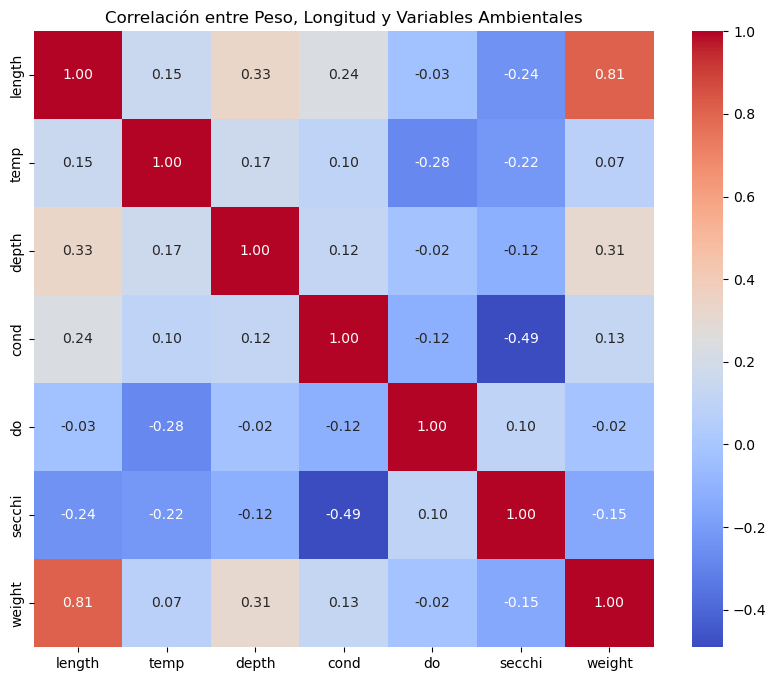

In [26]:
datos_numericos = df_limpio.select_dtypes(include="number") 
matriz_correlacion = datos_numericos.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre Peso, Longitud y Variables Ambientales")
plt.show()

##### Distibucion de los datos 

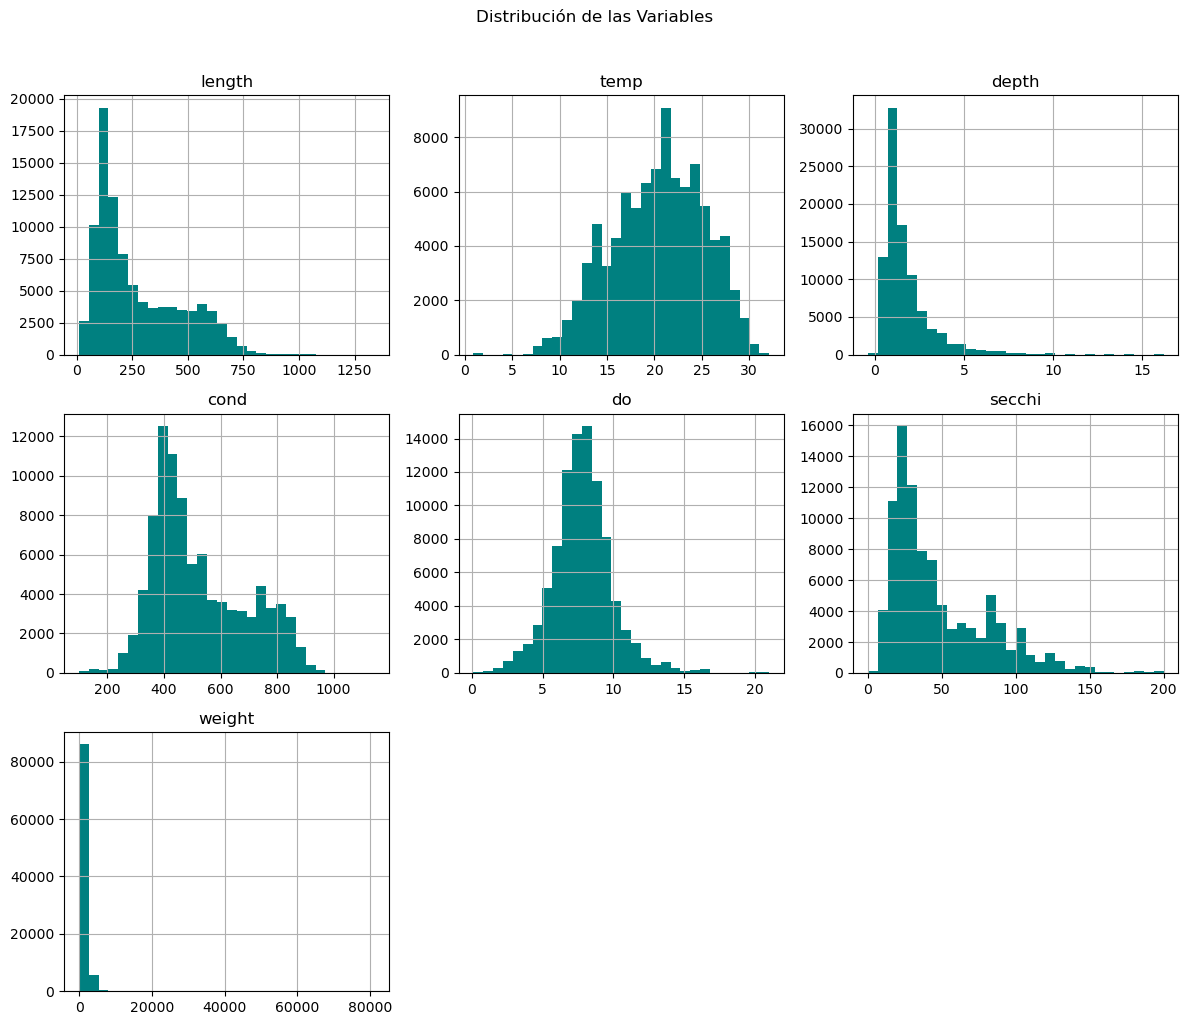

In [27]:
datos_numericos.hist(figsize=(12, 10), bins=30, color="teal")
plt.suptitle("Distribución de las Variables", y=1.02)
plt.tight_layout()
plt.show()

### Detección de Outliers (Boxplots)

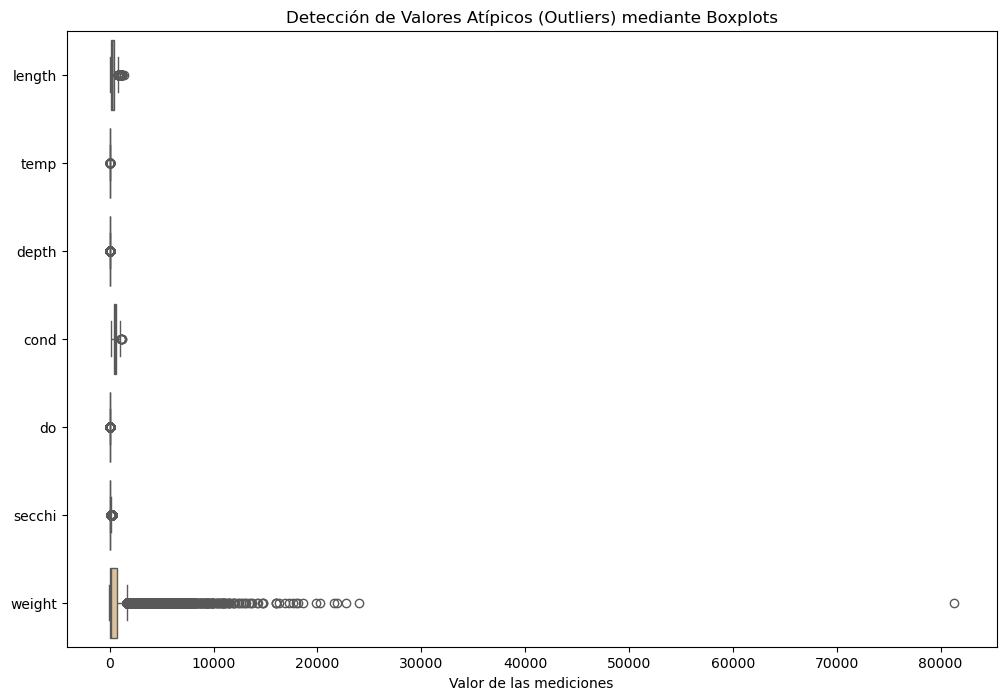

In [41]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=datos_numericos, orient="h", palette="Set2")
plt.title("Detección de Valores Atípicos (Outliers) mediante Boxplots")
plt.xlabel("Valor de las mediciones")
plt.show()

### Preprosesamiento y codificador de actergorias 

In [31]:
preprocesor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder="passthrough"
)

# Divicion del data set 80-20

In [32]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

X_train_scaled = preprocesor.fit_transform(X_train)
X_valid_scaled = preprocesor.transform(X_valid)

print(f"Entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Validación: {X_valid_scaled.shape[0]} muestras")

Entrenamiento: 73777 muestras
Validación: 18445 muestras


c:\Users\noe_l\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Modelos 

### Regresion Lineal 

 RESULTADOS: REGRESIÓN LINEAL


,Métrica,Valor
0,MAE,312.096517
1,MSE,281745.235041
2,RMSE,530.796793
3,R² (Validacion),0.787000
4,R² (Entrenamiento),0.771848


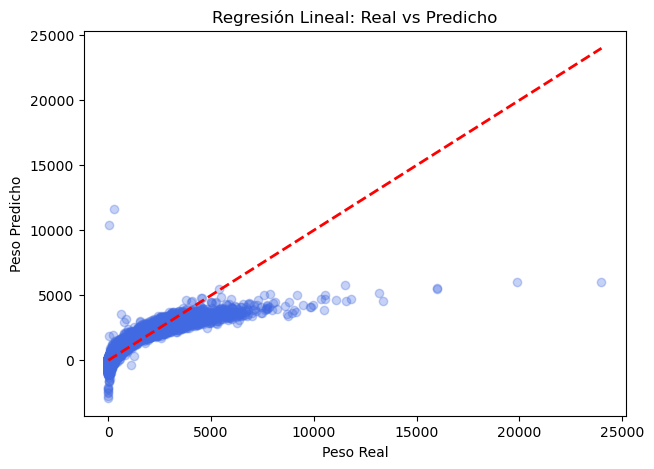

In [44]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_valid_scaled)
y_pred_train_lr = modelo_lr.predict(X_train_scaled)

mae_lr = mean_absolute_error(y_valid, y_pred_lr)
mse_lr = mean_squared_error(y_valid, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid, y_pred_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)

df_lr = pd.DataFrame({
    "Métrica": ("MAE", "MSE", "RMSE", "R² (Validacion)", "R² (Entrenamiento)"),
    "Valor": (mae_lr, mse_lr, rmse_lr, r2_lr, r2_train_lr)
})

print(" RESULTADOS: REGRESIÓN LINEAL")
display(df_lr)

plt.figure(figsize=(7, 5))
plt.scatter(y_valid, y_pred_lr, alpha=0.3, color='royalblue')
plt.plot((y_valid.min(), y_valid.max()), (y_valid.min(), y_valid.max()), 'r--', lw=2)
plt.title("Regresión Lineal: Real vs Predicho")
plt.xlabel("Peso Real")
plt.ylabel("Peso Predicho")
plt.show()

### LASSO

 RESULTADOS:


,Métrica,Valor
0,MAE,311.221426
1,RMSE,528.850511
2,R² (Precisión),0.788559
3,R² (Entrenamiento),0.770889


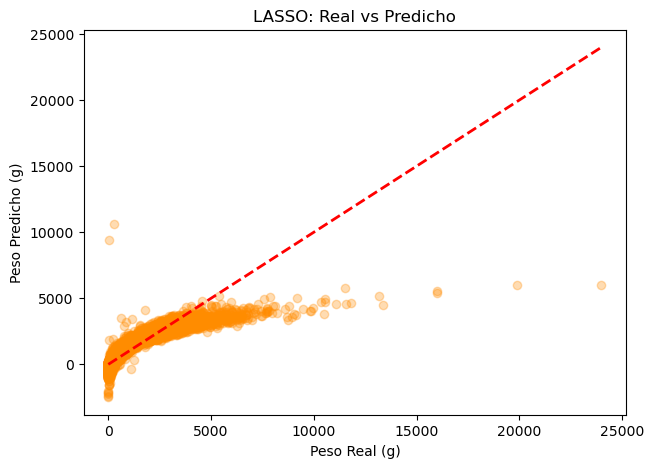

In [37]:
modelo_lasso = Lasso(alpha=0.1)
modelo_lasso.fit(X_train_scaled, y_train)

y_pred_lasso = modelo_lasso.predict(X_valid_scaled)
y_pred_train_lasso = modelo_lasso.predict(X_train_scaled)

mae_lasso = mean_absolute_error(y_valid, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_valid, y_pred_lasso))
r2_lasso = r2_score(y_valid, y_pred_lasso)
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)

df_lasso = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R² (Precisión)", "R² (Entrenamiento)"],
    "Valor": [mae_lasso, rmse_lasso, r2_lasso, r2_train_lasso ]
})

print(" RESULTADOS:")
display(df_lasso)

plt.figure(figsize=(7, 5))
plt.scatter(y_valid, y_pred_lasso, alpha=0.3, color='darkorange')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.title("LASSO: Real vs Predicho")
plt.xlabel("Peso Real (g)")
plt.ylabel("Peso Predicho (g)")
plt.show()

### KNN

MÉTRICAS: KNN 


,Métrica,Valor
0,MAE,112.453674
1,RMSE,340.087354
2,R² (Precisión),0.912561
3,R² (Entrenamiento),0.917739


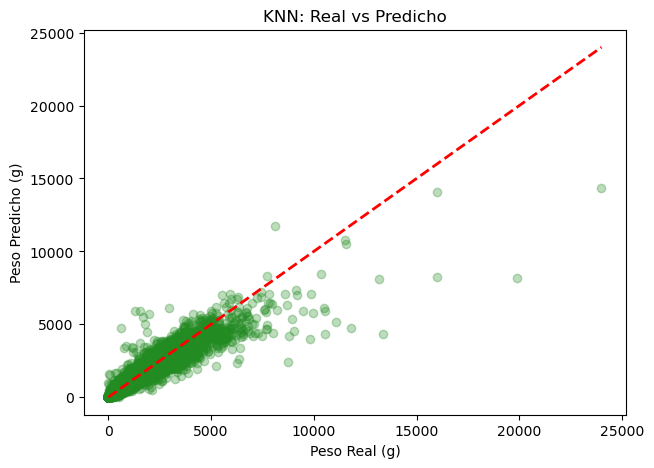

In [38]:
modelo_knn = KNeighborsRegressor(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)
y_pred_knn = modelo_knn.predict(X_valid_scaled)
y_pred_train_knn = modelo_knn.predict(X_train_scaled)

mae_knn = mean_absolute_error(y_valid, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_valid, y_pred_knn))
r2_knn = r2_score(y_valid, y_pred_knn)
r2_train_knn = r2_score(y_train, y_pred_train_knn)


df_knn = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R² (Precisión)", "R² (Entrenamiento)"],
    "Valor": [mae_knn, rmse_knn, r2_knn, r2_train_knn]
})
print("MÉTRICAS: KNN ")
display(df_knn)


plt.figure(figsize=(7, 5))
plt.scatter(y_valid, y_pred_knn, alpha=0.3, color='forestgreen')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.title("KNN: Real vs Predicho")
plt.xlabel("Peso Real (g)")
plt.ylabel("Peso Predicho (g)")
plt.show()

### Random Forest

MÉTRICAS: RANDOM FOREST


,Métrica,Valor
0,MAE,61.538266
1,RMSE,194.296495
2,R² (Precisión),0.971460
3,R² (Entrenamiento),0.986650


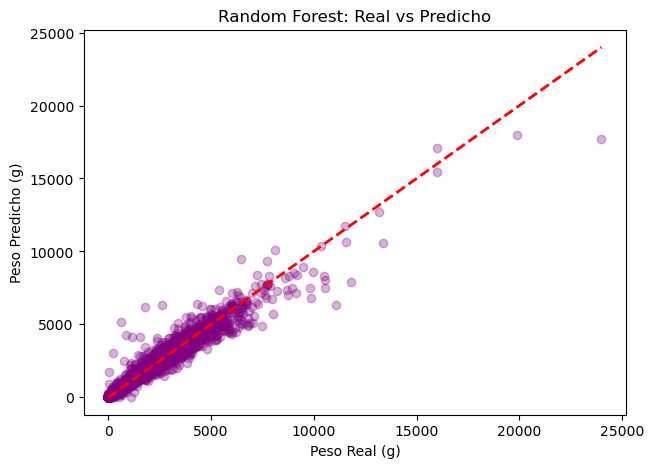

In [39]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)
y_pred_rf = modelo_rf.predict(X_valid_scaled)
y_pred_train_rf = modelo_rf.predict(X_train_scaled)

mae_rf = mean_absolute_error(y_valid, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
r2_rf = r2_score(y_valid, y_pred_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)


df_rf = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R² (Precisión)", "R² (Entrenamiento)"],
    "Valor": [mae_rf, rmse_rf, r2_rf, r2_train_rf]
})
print("MÉTRICAS: RANDOM FOREST")
display(df_rf)

plt.figure(figsize=(7, 5))
plt.scatter(y_valid, y_pred_rf, alpha=0.3, color='purple')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.title("Random Forest: Real vs Predicho")
plt.xlabel("Peso Real (g)")
plt.ylabel("Peso Predicho (g)")
plt.show()

### SVM

MÉTRICAS: SVM (Polinómico)


,Métrica,Valor
0,MAE,256.660522
1,RMSE,533.369506
2,R² (Precisión),0.784930
3,R² (Entrenamiento),0.746407


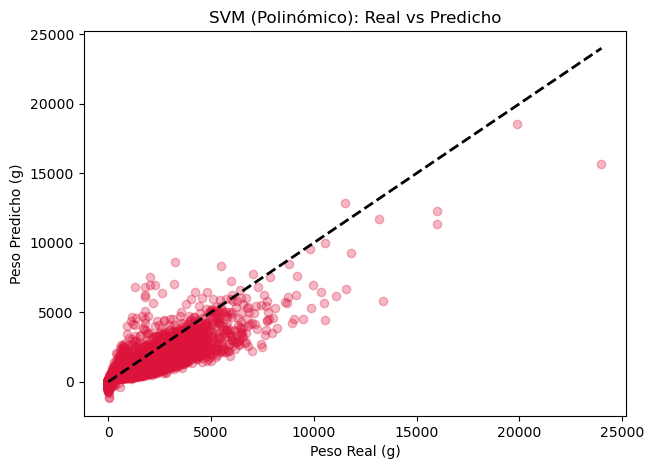

In [40]:
X_train_sample, y_train_sample = resample(X_train_scaled, y_train, 
                                          n_samples=73777, 
                                          random_state=42)

modelo_svr = SVR(kernel='poly')
modelo_svr.fit(X_train_sample, y_train_sample)

y_pred_svr = modelo_svr.predict(X_valid_scaled)
y_pred_train_svr = modelo_svr.predict(X_train_scaled)

mae_svr = mean_absolute_error(y_valid, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_valid, y_pred_svr))
r2_svr = r2_score(y_valid, y_pred_svr)
r2_train_svr = r2_score(y_train, y_pred_train_svr)

df_svr = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R² (Precisión)","R² (Entrenamiento)"],
    "Valor": [mae_svr, rmse_svr, r2_svr, r2_train_svr]
})
print("MÉTRICAS: SVM (Polinómico)")
display(df_svr)

plt.figure(figsize=(7, 5))
plt.scatter(y_valid, y_pred_svr, alpha=0.3, color='crimson')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'k--', lw=2)
plt.title("SVM (Polinómico): Real vs Predicho")
plt.xlabel("Peso Real (g)")
plt.ylabel("Peso Predicho (g)")
plt.show()

Importancia de variables(Random Forest) 


,Variable,Importancia
0,num__length,0.844493
75,cat__fishcode_SNGR,0.036600
49,cat__fishcode_LNGR,0.036176
47,cat__fishcode_LKSG,0.016726
21,cat__fishcode_CARP,0.010557
73,cat__fishcode_SMBF,0.009260
5,num__secchi,0.005193
3,num__cond,0.004987
2,num__depth,0.004969
4,num__do,0.004683


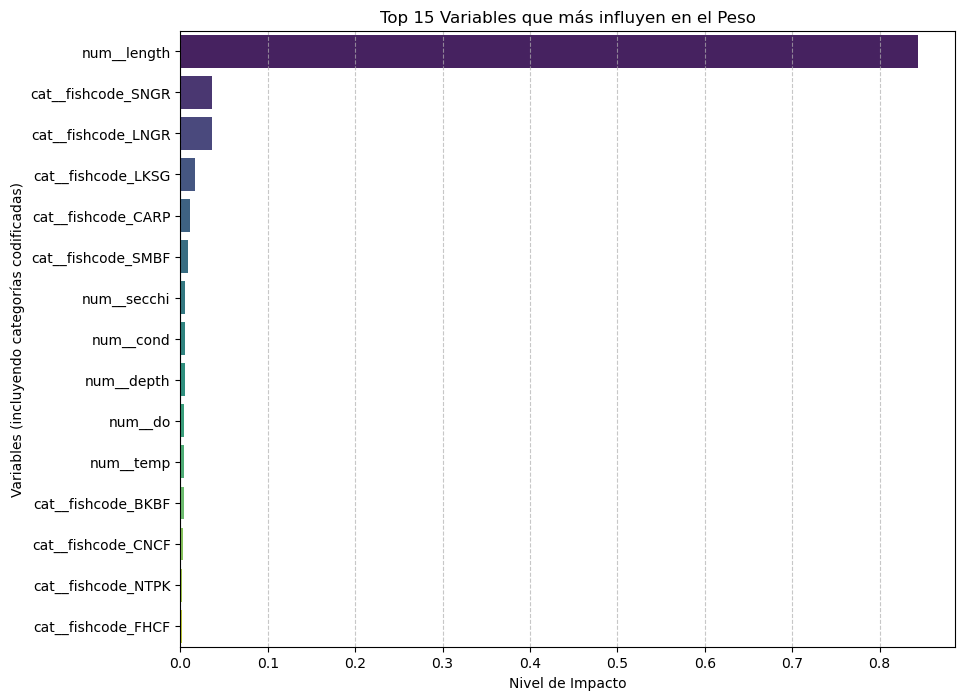

In [27]:
nombres_transformados = preprocesor.get_feature_names_out()
importancia = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    'Variable': nombres_transformados,
    'Importancia': importancia
}).sort_values(by='Importancia', ascending=False)

print("Importancia de variables(Random Forest) ")
display(df_importancia.head(10))


plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia.head(15), 
    palette='viridis',
    hue='Variable',
    legend=False
)

plt.title("Top 15 Variables que más influyen en el Peso")
plt.xlabel("Nivel de Impacto")
plt.ylabel("Variables (incluyendo categorías codificadas)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Comparativa de los modelos

 TABLA COMPARATIVA DE RENDIMIENTO 


,Modelo,MAE,RMSE,R² (Validación)
4,Random Forest,61.538266,194.296495,0.971460
2,KNN,112.453674,340.087354,0.912561
1,LASSO,311.221426,528.850511,0.788559
0,Regresión Lineal,312.096517,530.796793,0.787000
3,SVM (Poli),256.660522,533.369506,0.784930


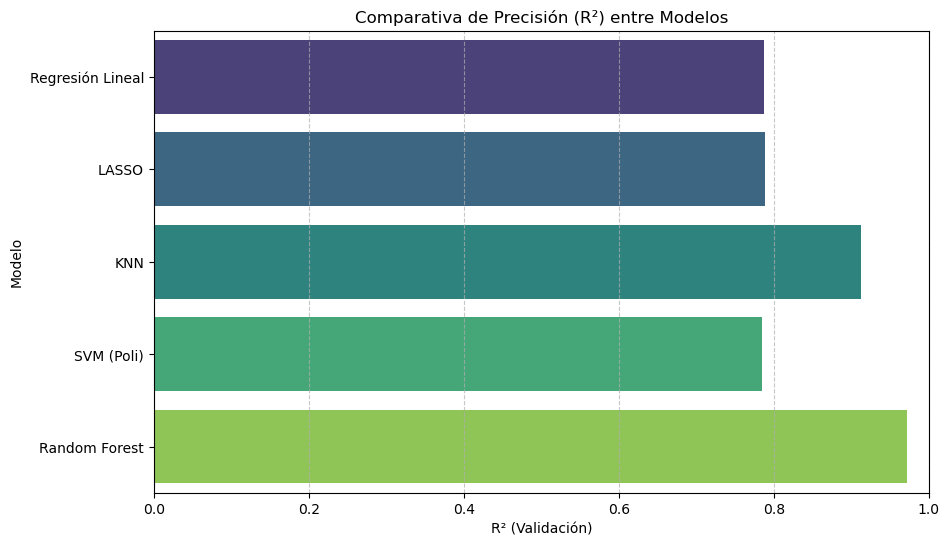

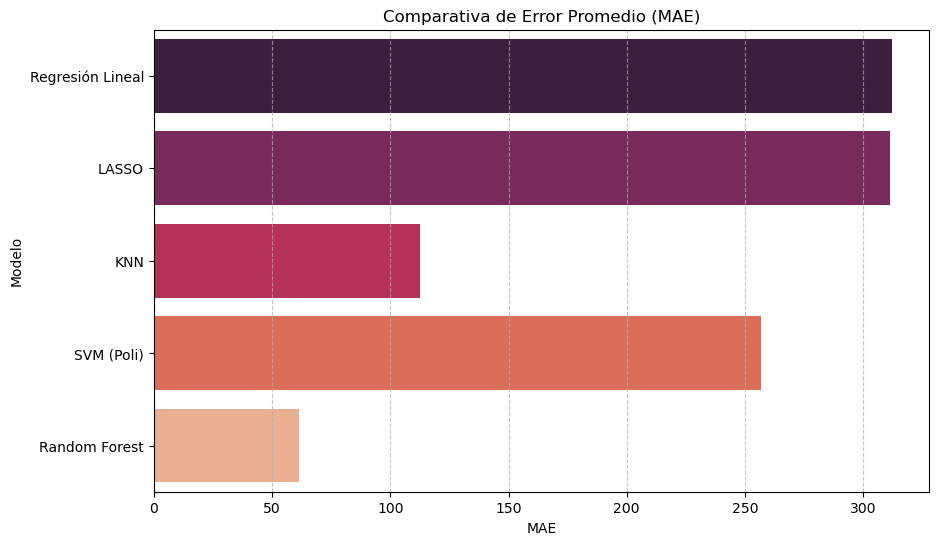

In [45]:
resultados_globales = pd.DataFrame({
    "Modelo": ("Regresión Lineal", "LASSO", "KNN", "SVM (Poli)", "Random Forest"),
    "MAE": (mae_lr, mae_lasso, mae_knn, mae_svr, mae_rf),
    "RMSE": (rmse_lr, rmse_lasso, rmse_knn, rmse_svr, rmse_rf),
    "R² (Validación)": (r2_lr, r2_lasso, r2_knn, r2_svr, r2_rf)
})

print(" TABLA COMPARATIVA DE RENDIMIENTO ")
display(resultados_globales.sort_values(by="R² (Validación)", ascending=False))


plt.figure(figsize=(10, 6))
sns.barplot(x="R² (Validación)", y="Modelo", data=resultados_globales, palette="viridis", hue="Modelo", legend=False)
plt.title("Comparativa de Precisión (R²) entre Modelos")
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Modelo", data=resultados_globales, palette="rocket", hue="Modelo", legend=False)
plt.title("Comparativa de Error Promedio (MAE)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()